<a href="https://colab.research.google.com/github/ignaciovgl/Multi-Asset-Trend-Following-Project/blob/main/Multi_asset_trend_following_backtest_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1: Data Infrastructure & Universe Selection — Goals

**Goals:**

- Build a multi-asset universe across 4 asset classes: equity indices, government bonds, FX majors, commodities
- Source data from free providers (yfinance), using a hybrid approach per instrument: real futures prices where available for free (US10Y, Gold, Crude, Copper), ETF proxies where futures data isn't freely available (Bund, Gilt)
- Maintain an INSTRUMENT_META table tagging each instrument's ticker, data source type, and asset class, to support source-aware decisions later (transaction costs, caveats in reporting)
- Pull maximum available history per instrument (targeting 2000–present), rather than truncating to the shortest series — preserving major macro regimes (2008 GFC, 2020 COVID) for instruments that have them
- Log actual data coverage per instrument (coverage_log.csv) and treat staggered start dates as expected, not an error — instruments enter the backtest on their own native start date
- Clean the data: forward-fill short genuine gaps (cross-exchange holiday mismatches), leave pre-inception NaNs untouched
- Convert prices to log returns as the common unit of measurement across all instruments
- Compute 21-day realised volatility (annualised) per instrument — foundation for volatility targeting in Phase 3
- Compute 63-day rolling correlations across instruments — foundation for portfolio-level risk accounting in Phase 3
- Milestone: clean, saved log_returns, realised_vol_21d, and rolling_corr_63d panels, ready to build signals on top of

## Update on phase 1
We started Week 1 by mapping the planned universe (equity indices, bonds, FX, commodities) onto actual free data sources, and hit a real constraint: yfinance doesn't provide back-adjusted futures for most instruments, and true continuous futures data (properly roll-adjusted) sits behind paid vendors. Rather than forcing a fake solution, we chose a per-instrument hybrid: real futures prices where yfinance actually offers them for free (ZN=F for US 10Y, GC=F/CL=F/HG=F for commodities), and liquid ETF proxies where no free futures exist (IS0L.DE for Bund, IGLT.L for Gilt). We accepted known, documentable tradeoffs on each side — unadjusted roll gaps in the futures series, expense-ratio drag and shorter history in the ETFs — rather than pretending the data is cleaner than it is. Because everything gets converted to daily log returns before any modeling happens, the pipeline itself is source-agnostic; the only thing we need to carry forward is a small metadata table tagging each instrument's source and asset class, so we can apply the right transaction-cost assumption later and flag caveats accurately in the final report.

In [3]:
!pip install yfinance pandas-market-calendars pyarrow -q

from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/trend_following_project'
os.makedirs(f'{PROJECT_DIR}/data/raw', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/data/processed', exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.3/213.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.5.0 requires toolz<1,>=0.11, but you have toolz 1.1.0 which is incompatible.
Mounted at /content/drive


In [4]:
INSTRUMENT_META = {
    'SPX':    {'ticker': '^GSPC',    'source': 'index',    'asset_class': 'equity'},
    'FTSE':   {'ticker': '^FTSE',    'source': 'index',    'asset_class': 'equity'},
    'DAX':    {'ticker': '^GDAXI',   'source': 'index',    'asset_class': 'equity'},
    'NIKKEI': {'ticker': '^N225',    'source': 'index',    'asset_class': 'equity'},

    'US10Y':  {'ticker': 'ZN=F',     'source': 'futures',  'asset_class': 'bond'},
    'BUND':   {'ticker': 'IS0L.DE',  'source': 'etf',      'asset_class': 'bond'},
    'GILT':   {'ticker': 'IGLT.L',   'source': 'etf',      'asset_class': 'bond'},

    'EURUSD': {'ticker': 'EURUSD=X', 'source': 'spot_fx',  'asset_class': 'fx'},
    'GBPUSD': {'ticker': 'GBPUSD=X', 'source': 'spot_fx',  'asset_class': 'fx'},
    'USDJPY': {'ticker': 'USDJPY=X', 'source': 'spot_fx',  'asset_class': 'fx'},
    'AUDUSD': {'ticker': 'AUDUSD=X', 'source': 'spot_fx',  'asset_class': 'fx'},

    'GOLD':   {'ticker': 'GC=F',     'source': 'futures',  'asset_class': 'commodity'},
    'CRUDE':  {'ticker': 'CL=F',     'source': 'futures',  'asset_class': 'commodity'},
    'COPPER': {'ticker': 'HG=F',     'source': 'futures',  'asset_class': 'commodity'},
}

import pandas as pd
meta_df = pd.DataFrame(INSTRUMENT_META).T
meta_df.to_csv(f'{PROJECT_DIR}/data/raw/instrument_meta.csv')
meta_df

,ticker,source,asset_class
SPX,^GSPC,index,equity
FTSE,^FTSE,index,equity
DAX,^GDAXI,index,equity
NIKKEI,^N225,index,equity
US10Y,ZN=F,futures,bond
BUND,IS0L.DE,etf,bond
GILT,IGLT.L,etf,bond
EURUSD,EURUSD=X,spot_fx,fx
GBPUSD,GBPUSD=X,spot_fx,fx
USDJPY,USDJPY=X,spot_fx,fx


In [5]:
import yfinance as yf

raw_data = {}
coverage_log = []

for name, meta in INSTRUMENT_META.items():
    ticker = meta['ticker']
    df = yf.download(ticker, start='2000-01-01', progress=False)
    if df.empty:
        print(f'WARNING: no data returned for {name} ({ticker})')
        coverage_log.append({'instrument': name, 'ticker': ticker, 'start': None, 'end': None, 'rows': 0})
        continue

    raw_data[name] = df['Close']
    coverage_log.append({
        'instrument': name, 'ticker': ticker,
        'start': df.index.min().date(), 'end': df.index.max().date(), 'rows': len(df)
    })
    df.to_csv(f'{PROJECT_DIR}/data/raw/{name}.csv')

coverage_df = pd.DataFrame(coverage_log)
coverage_df.to_csv(f'{PROJECT_DIR}/data/raw/coverage_log.csv', index=False)
coverage_df

/tmp/ipykernel_2043/1743732643.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2000-01-01', progress=False)
/tmp/ipykernel_2043/1743732643.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2000-01-01', progress=False)
/tmp/ipykernel_2043/1743732643.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2000-01-01', progress=False)
/tmp/ipykernel_2043/1743732643.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2000-01-01', progress=False)
/tmp/ipykernel_2043/1743732643.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2000-01-01', progress=False)
/tmp/ipykernel_2043/1743732643.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to 

,instrument,ticker,start,end,rows
0,SPX,^GSPC,2000-01-03,2026-07-13,6670
1,FTSE,^FTSE,2000-01-04,2026-07-13,6700
2,DAX,^GDAXI,2000-01-03,2026-07-13,6735
3,NIKKEI,^N225,2000-01-04,2026-07-13,6497
4,US10Y,ZN=F,2000-09-21,2026-07-13,6479
5,BUND,IS0L.DE,2012-05-08,2026-07-13,3594
6,GILT,IGLT.L,2008-01-02,2026-07-13,4680
7,EURUSD,EURUSD=X,2003-12-01,2026-07-13,5867
8,GBPUSD,GBPUSD=X,2003-12-01,2026-07-13,5879
9,USDJPY,USDJPY=X,2000-01-03,2026-07-10,6886


In [6]:
prices = pd.concat(raw_data, axis=1).sort_index()
prices.to_csv(f'{PROJECT_DIR}/data/raw/prices_combined.csv')
prices.tail()

,SPX,FTSE,DAX,NIKKEI,US10Y,BUND,GILT,EURUSD,GBPUSD,USDJPY,AUDUSD,GOLD,CRUDE,COPPER
Ticker,^GSPC,^FTSE,^GDAXI,^N225,ZN=F,IS0L.DE,IGLT.L,EURUSD=X,GBPUSD=X,USDJPY=X,AUDUSD=X,GC=F,CL=F,HG=F
Date,,,,,,,,,,,,,,
2026-07-07,7503.850098,10665.900391,25465.250000,68256.960938,109.328125,117.290001,9.6825,1.144178,1.339789,162.087997,0.695530,4145.299805,70.440002,6.1715
2026-07-08,7482.709961,10489.000000,24897.449219,66819.046875,109.000000,116.775002,9.5925,1.140381,1.334891,162.363007,0.692260,4070.899902,73.519997,6.0545
2026-07-09,7543.640137,10472.500000,25118.269531,67743.851562,109.265625,116.925003,9.6450,1.142204,1.339621,162.539001,0.693630,4130.600098,72.080002,6.2150
2026-07-10,7575.390137,10497.299805,25067.089844,68557.726562,109.031250,117.019997,9.6700,1.143341,1.341562,162.363007,0.694440,4104.100098,71.410004,6.2335
2026-07-13,7546.069824,10488.769531,25078.529297,67242.726562,108.796875,116.705002,9.6175,1.140381,1.337059,NaN,0.693385,4009.100098,74.400002,6.3215


In [7]:
# Forward-fill short genuine gaps (holiday mismatches across exchanges),
# but leave pre-inception NaNs alone — don't fabricate history
prices_clean = prices.ffill(limit=5)

nan_report = prices_clean.isna().sum()
print('Remaining NaNs per instrument (should mostly reflect pre-inception gaps):')
print(nan_report)

Remaining NaNs per instrument (should mostly reflect pre-inception gaps):
        Ticker  
SPX     ^GSPC          0
FTSE    ^FTSE          1
DAX     ^GDAXI         0
NIKKEI  ^N225          2
US10Y   ZN=F         190
BUND    IS0L.DE     3221
GILT    IGLT.L      2087
EURUSD  EURUSD=X    1026
GBPUSD  GBPUSD=X    1020
USDJPY  USDJPY=X       6
AUDUSD  AUDUSD=X    1661
GOLD    GC=F         172
CRUDE   CL=F         167
COPPER  HG=F         172
dtype: int64


In [9]:
import numpy as np

log_returns = np.log(prices_clean / prices_clean.shift(1))
realised_vol_21d = log_returns.rolling(21).std() * np.sqrt(252)
rolling_corr_63d = log_returns.rolling(63).corr()

log_returns.to_parquet(f'{PROJECT_DIR}/data/processed/log_returns.parquet')
realised_vol_21d.to_parquet(f'{PROJECT_DIR}/data/processed/realised_vol_21d.parquet')
rolling_corr_63d.to_parquet(f'{PROJECT_DIR}/data/processed/rolling_corr_63d.parquet')

print('Saved: log_returns, realised_vol_21d, rolling_corr_63d')

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


Saved: log_returns, realised_vol_21d, rolling_corr_63d


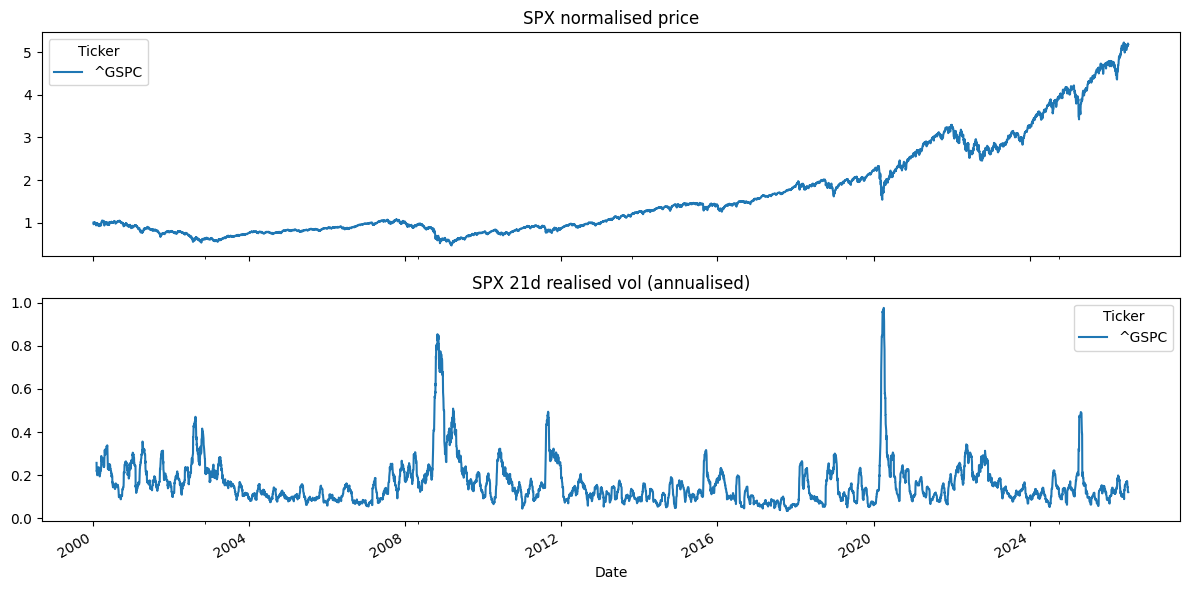

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
(prices_clean['SPX'] / prices_clean['SPX'].dropna().iloc[0]).plot(ax=axes[0], title='SPX normalised price')
realised_vol_21d['SPX'].plot(ax=axes[1], title='SPX 21d realised vol (annualised)')
plt.tight_layout()
plt.show()

## Explanation phase 1
All price series are converted to log returns rather than simple returns, since log returns are time-additive (returns over multiple periods simply sum, unlike simple returns which compound multiplicatively) and behave more symmetrically across instruments with very different price levels and volatility profiles. This makes them the standard choice whenever computing statistics on returns, as we do throughout this project.


From log returns we compute two key metrics that don't feed into the trading signals directly, but are essential inputs for portfolio construction in Week 3. Realised volatility (21-day rolling standard deviation of returns, annualised) measures how much each instrument is currently moving, and is the basis for volatility targeting — sizing each position so it contributes a comparable amount of risk to the portfolio, since a 1% daily move means something very different for EURUSD than for Gold.

Rolling correlation (63-day window) measures how instruments move together, which matters because portfolio-level risk depends not just on individual position sizes but on how those positions interact — diversification benefit shrinks (and can disappear entirely) when correlations rise, which they notably do during market stress (2008, 2020).

Tracking this on a rolling rather than static basis lets the portfolio construction step account for changing regimes rather than assuming a fixed average relationship that breaks down exactly when it matters most.

Note also that instruments enter the dataset on their own native start dates (see coverage_log.csv) rather than being truncated to a common window — this preserves 12+ years of history (including the 2008 GFC) for instruments like equities, US10Y futures, and commodities that would otherwise be discarded to accommodate later-starting series like the Bund ETF proxy (2012).

Downstream signal and portfolio logic is written to operate on whatever instruments have valid data on a given date, rather than assuming a fixed, static universe throughout the backtest.

# Phase 2: Signal Construction — Goals

- Implement at least 3 trend-following signals:

   - EWMA crossover (fast/slow window pairs)
   - Time series momentum (12-1 month return)
   - Donchian channel breakout
- Normalise each signal to a [-1, +1] range to make them directly comparable and combinable
- Combine signals into a composite score:
    - Start with equal weighting across signals
    - Then test a risk-weighted combination
- Visually validate signals against price for 4–5 instruments — confirm signals behave intuitively at known trend/reversal points
- Handle the staggered universe correctly: signals should only be computed/considered valid for instruments with sufficient live history at each point in time
- Milestone: a clean signal matrix (instruments × dates) saved as a DataFrame, ready for position sizing in Phase 3

## Development of trend-following signals
Three complementary trend-following signals are constructed, each capturing a different aspect of trend behaviour.

EWMA crossover compares fast and slow exponentially-weighted moving averages across multiple time horizons, capturing whether recent price action is outpacing the longer-term trend.

Time series momentum (12-1 month) measures the return over the past year, excluding the most recent month to avoid short-term mean-reversion effects well documented in the momentum literature, capturing longer-horizon persistence.

Donchian channel breakout measures where price sits relative to its recent high-low range, capturing genuine breakouts from consolidation rather than smoothed trend strength.

Each raw signal is normalised using its own rolling historical spread and squashed with tanh to a common [-1, +1] scale, making the three directly comparable despite being computed on entirely different bases (percentage-of-price, period return, and range position respectively).

This diversity is intentional: combining signals with different mechanisms and horizons produces a more robust composite than relying on any single trend measure, and is standard practice in systematic trend-following strategies.

### EWMA Crossover

In [18]:
def ewma_crossover_signal(prices, pairs=[(8, 32), (16, 64), (32, 128)]):
    """
    prices: DataFrame (dates x instruments)
    pairs: list of (fast_span, slow_span) tuples
    Returns: DataFrame of raw (unnormalised) crossover signal, averaged across pairs
    """
    signals = []
    for fast_span, slow_span in pairs:
        fast_ema = prices.ewm(span=fast_span, min_periods=fast_span).mean()
        slow_ema = prices.ewm(span=slow_span, min_periods=slow_span).mean()
        # Scale by price so the raw signal is comparable across instruments
        # regardless of absolute price level (e.g. Nikkei ~30000 vs EURUSD ~1.1)
        raw_signal = (fast_ema - slow_ema) / prices
        signals.append(raw_signal)

    combined = sum(signals) / len(signals)
    return combined

ewma_raw = ewma_crossover_signal(prices_clean)

In [ ]:
def check_signal(raw_signal, norm_signal, prices, instrument, signal_name, n_years=5):
    """
    Generic check: plots price, raw signal, and normalised signal together,
    and prints basic sanity stats.
    """
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    # Correctly access the specific Series using the full MultiIndex column name
    # Assuming INSTRUMENT_META is available in the global scope
    instrument_ticker = INSTRUMENT_META[instrument]['ticker']
    full_column_name = (instrument, instrument_ticker)

    # Get the specific Series for prices, raw_signal, and norm_signal
    prices_series = prices[full_column_name]
    raw_signal_series = raw_signal[full_column_name]
    norm_signal_series = norm_signal[full_column_name]

    # Address FutureWarning: use .loc for filtering instead of .last()
    # Assuming 'prices_series' has a DatetimeIndex
    if hasattr(prices_series, 'index') and isinstance(prices_series.index, pd.DatetimeIndex):
        end_date = prices_series.index.max()
        start_date = end_date - pd.Timedelta(days=n_years * 365)
        recent = prices_series.loc[start_date:end_date]
    else:
        recent = prices_series.tail(n_years * 252)

    prices_series.plot(ax=axes[0], title=f'{instrument} price')

    raw_signal_series.plot(ax=axes[1], title=f'{instrument} {signal_name} — raw')
    axes[1].axhline(0, color='black', linewidth=0.5)

    norm_signal_series.plot(ax=axes[2], title=f'{instrument} {signal_name} — normalised [-1,1]')
    axes[2].axhline(0, color='black', linewidth=0.5)
    axes[2].set_ylim(-1.1, 1.1)

    plt.tight_layout()
    plt.show()

    print(f'--- {signal_name} sanity stats for {instrument} ---')
    print(f'Raw signal: min={raw_signal_series.min():.4f}, max={raw_signal_series.max():.4f}, '
          f'mean={raw_signal_series.mean():.4f}')
    print(f'Normalised signal: min={norm_signal_series.min():.4f}, max={norm_signal_series.max():.4f}, '
          f'% positive={100 * (norm_signal_series.dropna() > 0).mean():.1f}%')
    print(f'NaN count: {norm_signal_series.isna().sum()} / {len(norm_signal_series)}\n')

# Check EWMA on a couple of instruments
for inst in ['SPX', 'GOLD']:
    check_signal(ewma_raw, ewma_norm, prices_clean, inst, 'EWMA Crossover')

### Time Series Momentum (12-1 month)

In [19]:
def tsmom_signal(prices, lookback_months=12, skip_months=1):
    """
    12-1 month momentum: return from t-252 to t-21, skipping the most recent month
    Approximating months as 21 trading days each
    """
    lookback_days = lookback_months * 21
    skip_days = skip_months * 21

    price_then = prices.shift(lookback_days)
    price_recent = prices.shift(skip_days)

    raw_signal = (price_recent / price_then) - 1
    return raw_signal

tsmom_raw = tsmom_signal(prices_clean)

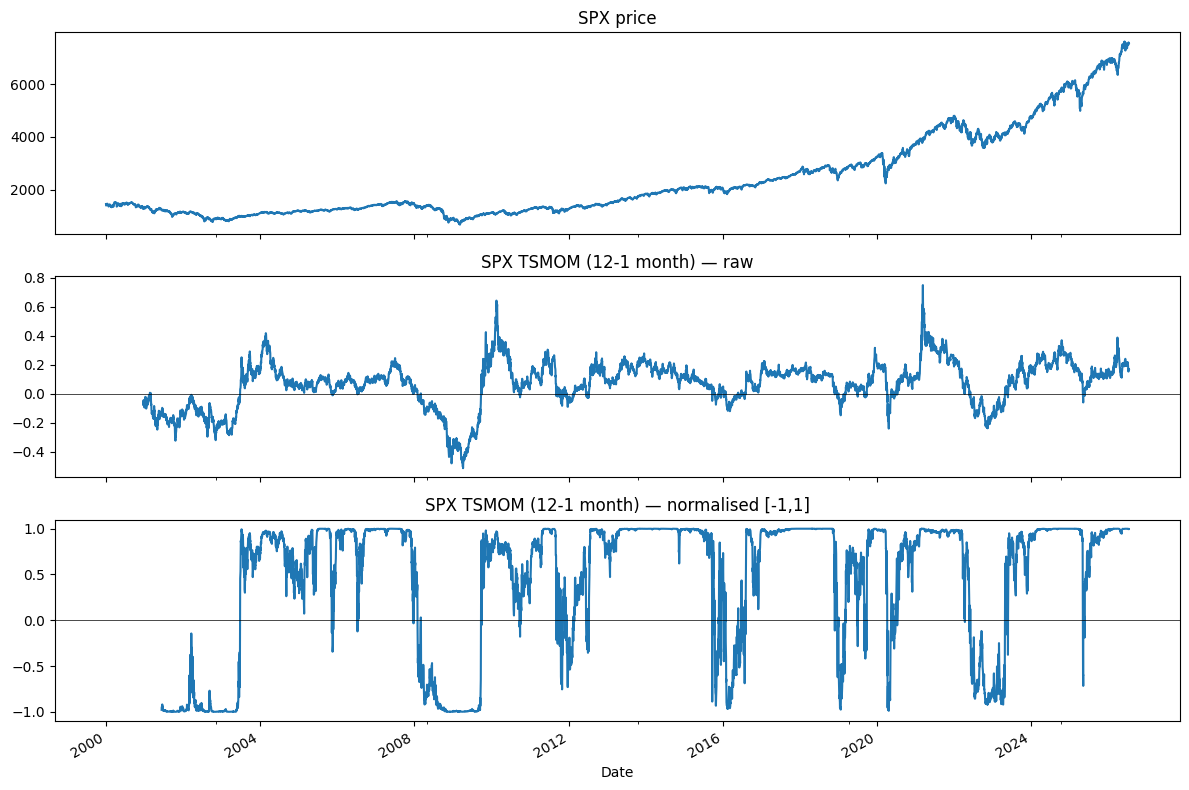

--- TSMOM (12-1 month) sanity stats for SPX ---
Raw signal: min=-0.5134, max=0.7481, mean=0.0681
Normalised signal: min=-0.9999, max=1.0000, % positive=75.4%
NaN count: 377 / 6919



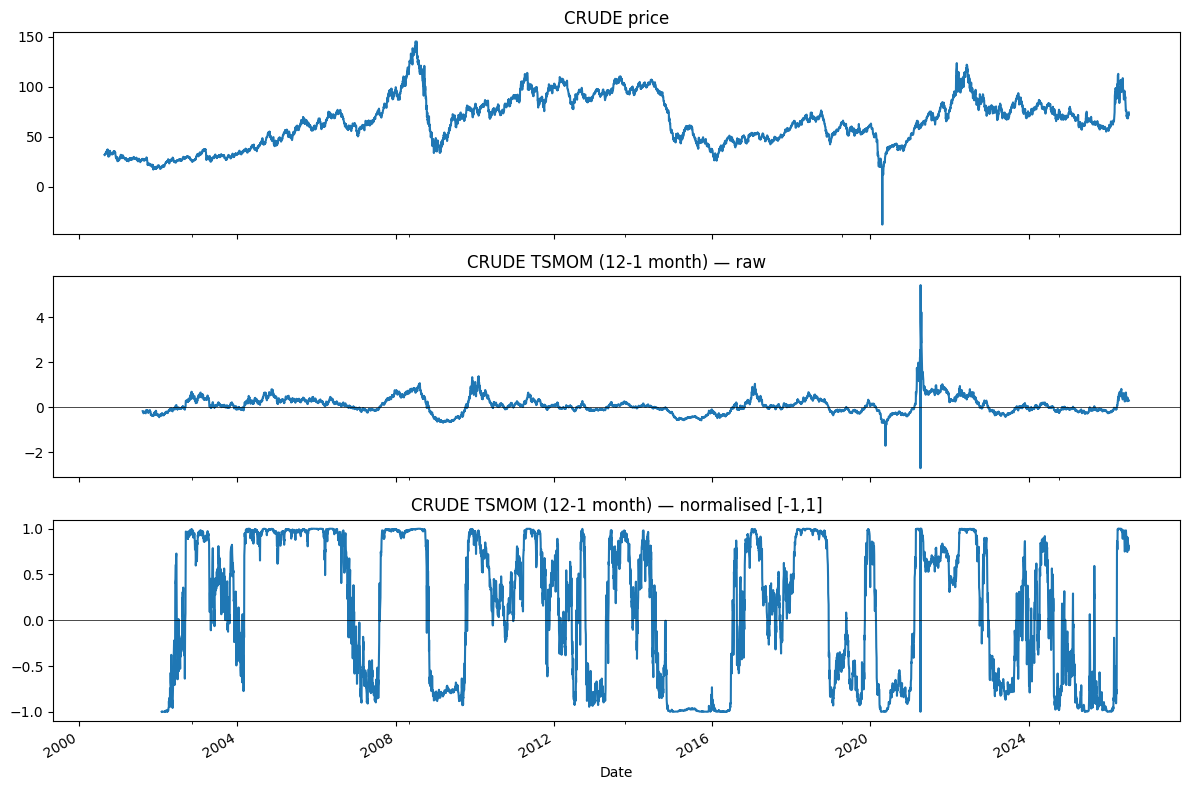

--- TSMOM (12-1 month) sanity stats for CRUDE ---
Raw signal: min=-2.7010, max=5.4376, mean=0.0899
Normalised signal: min=-1.0000, max=1.0000, % positive=57.9%
NaN count: 544 / 6919

TSMOM vs naive 12m momentum — mean abs difference: 0.0352
(should be small but non-zero — confirms the skip-month logic is doing something, not accidentally identical to naive momentum)


In [28]:
for inst in ['SPX', 'CRUDE']:
    check_signal(tsmom_raw, tsmom_norm, prices_clean, inst, 'TSMOM (12-1 month)')

# Extra check specific to TSMOM: verify it's genuinely skipping the last month
# by comparing to naive (non-skipped) 12-month momentum
# Corrected: Naive 12-month momentum should NOT skip the last month.
naive_12m = (prices_clean / prices_clean.shift(252)) - 1

# Access the specific column for SPX momentum for comparison
spx_tsmom_raw = tsmom_raw[('SPX', INSTRUMENT_META['SPX']['ticker'])]
spx_naive_12m = naive_12m[('SPX', INSTRUMENT_META['SPX']['ticker'])]

diff = (spx_tsmom_raw - spx_naive_12m).dropna()
print(f'TSMOM vs naive 12m momentum — mean abs difference: {diff.abs().mean():.4f}')
print('(should be small but non-zero — confirms the skip-month logic is doing something, '
      'not accidentally identical to naive momentum)')

### Donchian Channel

In [20]:
def donchian_signal(prices, window=50):
    """
    Donchian channel: signal = where price sits within the recent high-low range,
    scaled to roughly [-1, 1] before it goes into the general normalisation step
    """
    rolling_high = prices.rolling(window, min_periods=window).max()
    rolling_low = prices.rolling(window, min_periods=window).min()
    mid = (rolling_high + rolling_low) / 2
    half_range = (rolling_high - rolling_low) / 2

    raw_signal = (prices - mid) / half_range  # already roughly bounded, but not exactly
    return raw_signal

donchian_raw = donchian_signal(prices_clean)

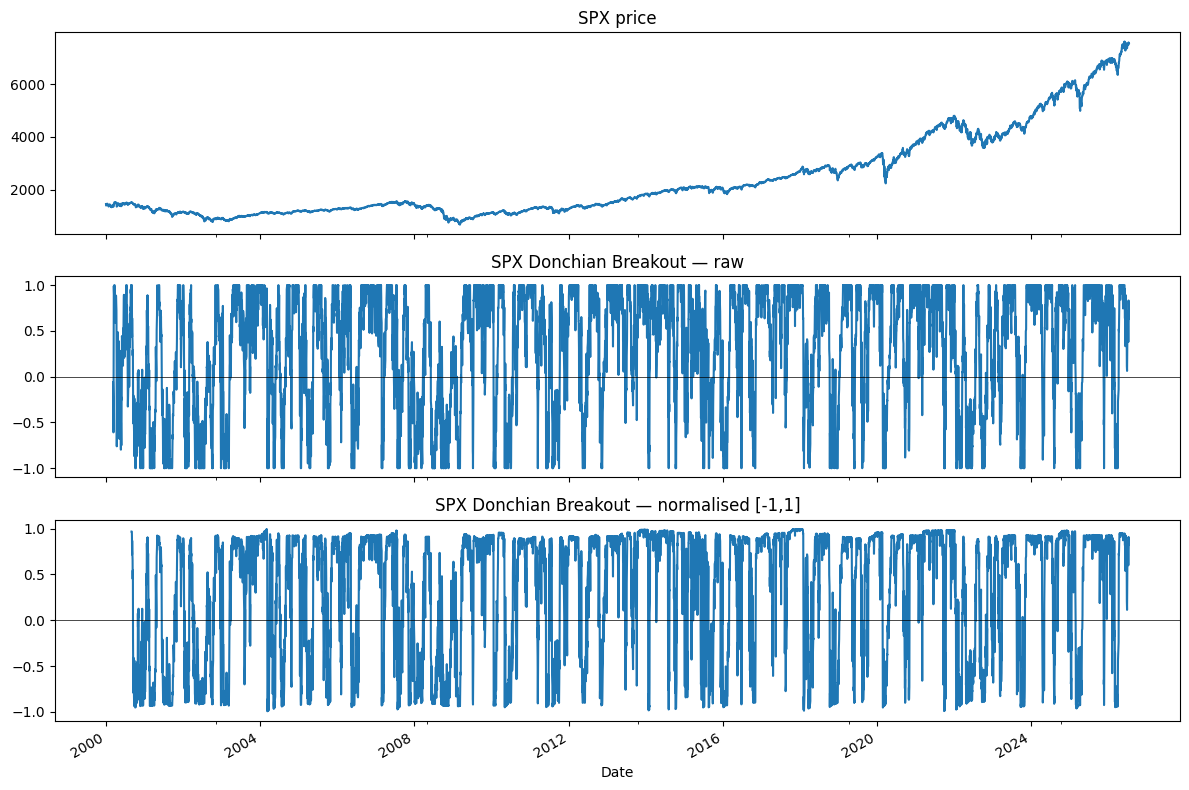

--- Donchian Breakout sanity stats for SPX ---
Raw signal: min=-1.0000, max=1.0000, mean=0.3268
Normalised signal: min=-0.9939, max=0.9945, % positive=69.2%
NaN count: 174 / 6919



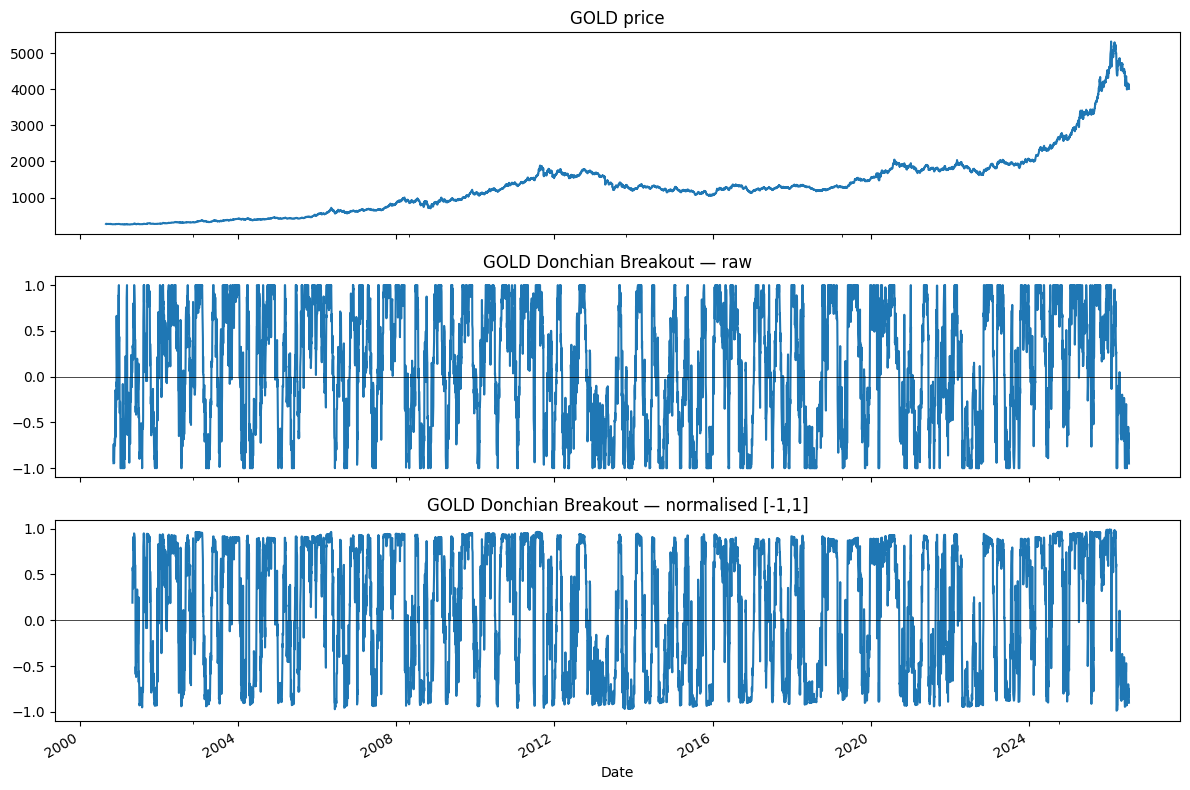

--- Donchian Breakout sanity stats for GOLD ---
Raw signal: min=-1.0000, max=1.0000, mean=0.1287
Normalised signal: min=-0.9871, max=0.9896, % positive=57.6%
NaN count: 346 / 6919

SPX all-time high on 2026-06-02: Donchian normalised = 0.948 (should be strongly positive, near +1)
SPX 2020 crash low on 2020-03-23: Donchian normalised = -0.913 (should be strongly negative, near -1)


In [30]:
for inst in ['SPX', 'GOLD']:
    check_signal(donchian_raw, donchian_norm, prices_clean, inst, 'Donchian Breakout')

# Extra check specific to Donchian: confirm sign convention is correct
# by checking signal value on the exact date of a known all-time high and a known crash low
spx_ath_date = prices_clean['SPX'].idxmax()
spx_crash_low_2020 = prices_clean['SPX']['2020-02-01':'2020-04-01'].idxmin()

print(f"SPX all-time high on {spx_ath_date.iloc[0].date()}: Donchian normalised = "
      f"{donchian_norm.loc[spx_ath_date.iloc[0], ('SPX', INSTRUMENT_META['SPX']['ticker'])]:.3f} (should be strongly positive, near +1)")
print(f"SPX 2020 crash low on {spx_crash_low_2020.iloc[0].date()}: Donchian normalised = "
      f"{donchian_norm.loc[spx_crash_low_2020.iloc[0], ('SPX', INSTRUMENT_META['SPX']['ticker'])]:.3f} (should be strongly negative, near -1)")

### Combined Signal

In [14]:
import numpy as np

def normalise_signal(raw_signal, scale_window=252):
    """
    Normalise using rolling standard deviation of the signal itself,
    then squash to [-1, 1] with tanh so extreme values don't dominate
    """
    rolling_std = raw_signal.rolling(scale_window, min_periods=scale_window//2).std()
    z = raw_signal / rolling_std
    normalised = np.tanh(z)
    return normalised

ewma_norm = normalise_signal(ewma_raw)
tsmom_norm = normalise_signal(tsmom_raw)
donchian_norm = normalise_signal(donchian_raw)

In [15]:
composite_signal = (ewma_norm + tsmom_norm + donchian_norm) / 3
composite_signal.to_parquet(f'{PROJECT_DIR}/data/processed/composite_signal_equal_weight.parquet')

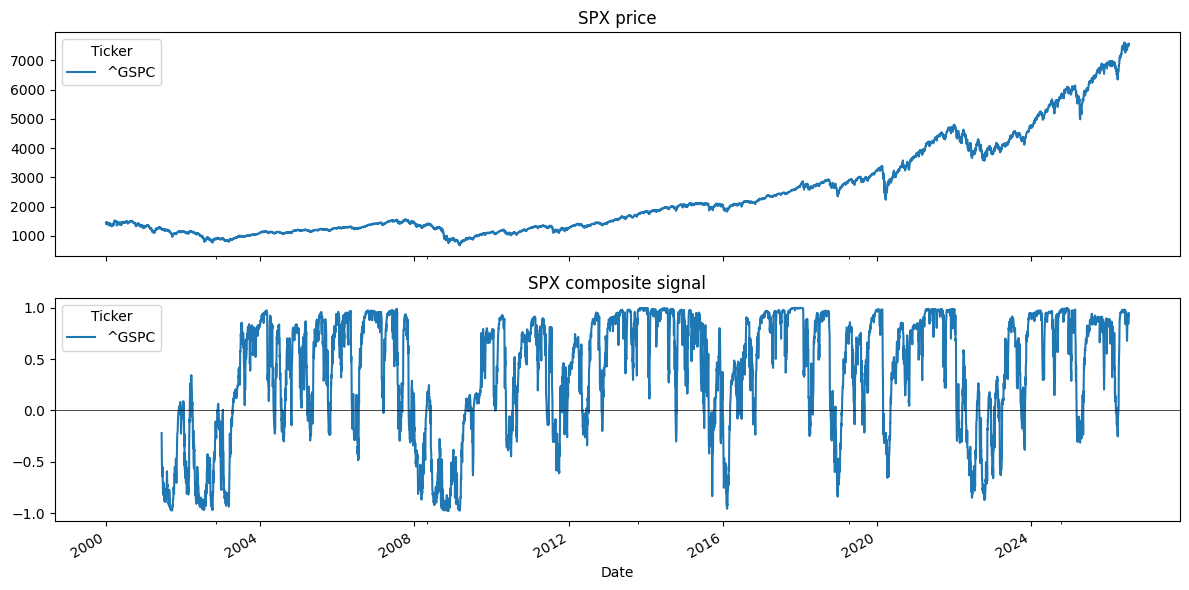

In [16]:
import matplotlib.pyplot as plt

instrument = 'SPX'
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
prices_clean[instrument].plot(ax=axes[0], title=f'{instrument} price')
composite_signal[instrument].plot(ax=axes[1], title=f'{instrument} composite signal')
axes[1].axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()